<a href="https://colab.research.google.com/github/Erica97/Erica97.github.io/blob/master/Vandalism_in_Wikipedia_edits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
    <h1>Using Classification and Regression Trees (CART) and Random Forest to identify Vandalism in Wikipedia</h1>
    <hr>
    <h3>Erica Li</h3>
    <h3>September 22, 2019</h3>
</center>


# Project Background
Wikipedia is the world’s largest free online encyclopedia, containing in the neighbourhood of 5.8 million articles with roughly 156,000 edits per day. Wikipedia allows anyone to contribute/edit entries, which promotes rapid content creation and community-based error checking. An unfortunate side effect of this approach is the presence of vandalism. Specifically, we refer to pages that have had information removed, incorrect information added, or the presence of inappropriate content. Due to the volume of entries being changed on a daily basis, it is incredibly diffcult to manually (i.e., human checking) ensure the accuracy of pages and remove any instances of vandalism.

The goal of the project is to investigate vandalism in Wikipedia (en.wikipedia.org). We will look at a dataset that summarizes the revision history for the “Language” entry on Wikipedia (en.wikipedia.org/wiki/Language) and conduct some exploratory data analysis (EDA) and look into predicting whether a particular revision was an instance of vandalism or not. 


In [0]:
# Import packages
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv('https://docs.google.com/uc?export=download&id=1la-cSzyr8RjehjLv-g4g7KGaQmJWRCc2') 
df.head() # prints the first 5 rows of the dataframe 

,Vandal,Minor,LoggedIn,HTTP,NumWordsAdded,NumWordsRemoved
0,0,1,1,1,96,0
1,0,1,1,0,3,1
2,0,0,1,0,0,4
3,0,1,0,0,10,92
4,0,1,1,1,94,10


The table below contains the data dictionary.

|Feature          |Definition                                             |
|:---------------:|:------------------------------------------------------|
|Vandal           |1 if the edit was vandalism, 0 if not                  |
|Minor            |1 if the edit was marked as a minor edit, 0 if not     |    
|LoggedIn         |1 if the user made edit from Wiki account, 0 if not    |
|HTTP             |1 if edit contained web address, 0 if not              | 
|NumWordsAdded    |Number of unique words added                           |
|NumWordsRemoved  |Number of unique words removed                         |


## Exploratory data analysis
Prior to using CART and random forests to make predictions, we start with EDA to get a better feel for the Wikipedia dataset we are using. We will examine if there are any non-numeric variables, then drop all the missing values.

In [0]:
# df_digit_indicator is calculated below to get you started. 
df_digit_indicator = df.applymap(lambda x: x.isdigit())  

# Write your code here.  

# -------------------

number_non_digits = (df_digit_indicator==0).sum()

print('There are non-numerical values as follows \n{} '.format(number_non_digits))

# -------------------

There are non-numerical values as follows 
Vandal             2
Minor              1
LoggedIn           2
HTTP               1
NumWordsAdded      2
NumWordsRemoved    1
dtype: int64 


In [0]:
# Write your code here.  

# -------------------

for col in df.columns:
  print(df[col][df_digit_indicator[col] == False].value_counts())

# -------------------

ERROR    2
Name: Vandal, dtype: int64
ERROR    1
Name: Minor, dtype: int64
ERROR    2
Name: LoggedIn, dtype: int64
ERROR    1
Name: HTTP, dtype: int64
ERROR    2
Name: NumWordsAdded, dtype: int64
ERROR    1
Name: NumWordsRemoved, dtype: int64


Now that we have identified some issues with the data we should clean it and insure all the entries are integer.

3. Remove any invalid datapoints from df. Use this new df for the remainder of this lab.

In [0]:
# Write your code here.  

# -------------------

df = df.replace('ERROR', np.nan)
df = df.dropna()

#df = df.loc[df_digit_indicator.min(axis=1)]

# -------------------

# Once the rows are deleted (or even before) it's important to ensure
# that all elements in this df are numeric. The code below will change
# strings to numeric values. 

df = df.apply(pd.to_numeric, errors='coerce')

It will be easier to contiue the EDA now that we have clean data in ```df```.

4. How many edits are considered? 

In [0]:
# Write your code here.  

# -------------------

number_of_edits = len(df)
print('There are {} edits considered.'.format(number_of_edits))

# -------------------

There are 3867 edits considered.


5. What percentage of the edits were deemed to be vandalism?

In [0]:
# Write your code here.  

# -------------------

percent_vandal = df['Vandal'].mean()*100
print('{:.2f}% of the edits were vandalism.'.format(percent_vandal))

# -------------------

46.75% of the edits were vandalism.


6. Was the edit with the most added words a case of vandalism?

In [0]:
# Write your code here.  

# -------------------

most_words_added_vandal_index = df.NumWordsAdded.loc[df.Vandal==1].idxmax()
most_words_added_by_vandal = df.NumWordsAdded.loc[most_words_added_vandal_index]
print('Of all vandal edits, {} added the most words ({}).'.format(most_words_added_vandal_index,most_words_added_by_vandal))

# -------------------

Of all vandal edits, 2829 added the most words (138).


7. Based on a cursory review of the dataset, which two feature variables (e.g., Minor, LoggedIn, HTTP, NumWordsAdded, and NumWordsRemoved) do you believe to be the most significant in predicting vandalism? Why?

___
## __Answer__:

___

## Splitting the Data
Randomly split data clean into a training set and test set, named data train and data test, respectively. We will place 70% of the data into the training set and the remainder in the test set.

In [0]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('Vandal',1), df['Vandal'], test_size=0.30, random_state=5)


Answer the following questions:

1. How many points are in the training set?

In [0]:
# Write your code here.  

# -------------------

len(y_train)

# -------------------

2706

2. How many confirmed vandalisms are in y_train?

In [0]:
# Write your code here.  

# -------------------

sum(y_train)

# -------------------

1257

# Using CART and RF with sklearn

In the next section we will go over how the use the CART and RF classifers in sklearn. The purpose of both of these methods is to classify target variables (e.g., Wikipedia edit is or is not vandelized), hence, these methods are more similar to logistic regression than they are to linear regession. Note, that random forest regession is also available in sklearn, which should be used instead of the classifers if you're looking for a model to predict continuous values between positive and negative infinity (e.g., number of edits).


## CART Model

Use the ```DecisionTreeClassifier``` function within ```sklearn.tree```  to fit a CART model to the training set. There are several parameters that you can tune to prevent over fitting and to get better model accuracy. Recall that cross validation should be used to pick the best parameters for the model, but for simplicity we will neglect that step in this lab. One parameter you can set is _max_depth_, which controls the maximum number of levels in your trained model. In the example below we set the _max_depth_ to three and visualize the resulting tree.  Figure 2 illustrates what a possible CART tree could look like for this application. Based on your produced tree, answer the following questions:


The score of this model over training data is 0.730 and 0.717 over the testing data


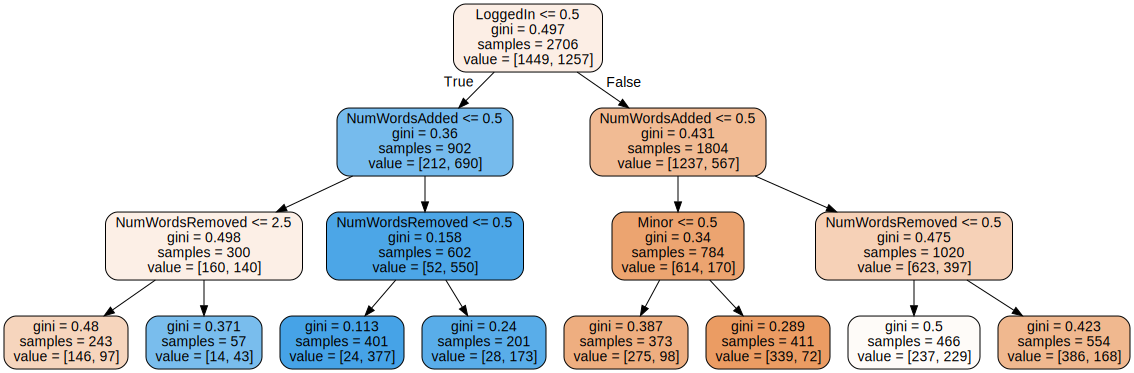

In [0]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from subprocess import call
from IPython.display import SVG
from graphviz import Source

# Train the CART model
cart_model = DecisionTreeClassifier(random_state=3,max_depth=3)
cart_model.fit(x_train, y_train)
train_score = cart_model.score(x_train, y_train)
test_score = cart_model.score(x_test, y_test)

# Print out summary of model performance 
print('The score of this model over training data is {:.3f} and {:.3f} over the testing data'.format(train_score, test_score))

# Visualize the decision tree
cart_graph = Source(export_graphviz(cart_model,
                   feature_names = df.columns[1:],
                   rounded = True, proportion = False, 
                  filled = True))
SVG(cart_graph.pipe(format='svg'))

Based on the tree, answer the following questions:
1. How many nodes are in the tree? You can count on the image, or use the method _tree_.node_count_ on your model.

In [0]:
# Write your code here.  

# -------------------

cart_model.tree_.node_count

# -------------------

15

2. Which feature variable is split at the root node?

___
## __Answer__:
LoggedIn
___

3. Using the feature_importances_ method on your model, which of the feature variables are important?

In [0]:
# Write your code here.

# -------------------

pd.Series(cart_model.feature_importances_, index=x_train.columns)

# -------------------

Minor              0.007789
LoggedIn           0.634670
HTTP               0.000000
NumWordsAdded      0.276306
NumWordsRemoved    0.081235
dtype: float64

4. Assess the accuracy of your model on the testing set. What % of predictions are correct?

In [0]:
# Write your code here.  

# -------------------

cart_model.fit(x_test, y_test)
mdlAcc = np.mean((cart_model.predict(x_test) == y_test))
print('The accuracy of this model on the training data is {:.3f}'.format(round(mdlAcc,3)))

# -------------------

The accuracy of this model on the training data is 0.721


5. Constrain the maximum depth to 10. What is the new accuracy of the model on the training and testing set? Do you think this model has overfit the data?

In [0]:
# Write your code here.

# -------------------

cart_model = DecisionTreeClassifier(random_state=0,max_depth=10)
cart_model.fit(x_train, y_train)
mdlAccTrain = np.mean((cart_model.predict(x_train) == y_train))
mdlAccTest = np.mean((cart_model.predict(x_test) == y_test))

print('The accuracy on the: \n\t training data is {}'.format(round(mdlAccTrain,3)))
print('\t testing data is {}'.format(round(mdlAccTest,3)))

# -------------------

The accuracy on the: 
	 training data is 0.773
	 testing data is 0.721


Throughout this lab we will fit and "score" models several time, so to be efficent (and to follow good coding practice!) we should make a function that fits and scores a model. For future labs and projects you should try to introduce functions where possible. 

In [0]:
def fit_and_score_model(mdl, x_train, x_test, y_train, y_test, random_state=0):
    """
    This function will fit and score the input mdl to the x_train and y_train 
    data, and score the mdl on y_train and y_test. To ensure results are 
    reproducible we can also set a random state.
    """
  
    # Fit an arbitrary model
    mdl.fit(x_train, y_train)
    
    # Calculate the score of the model on training and testing data
    train_score = mdl.score(x_train, y_train)
    test_score = mdl.score(x_test, y_test)
  
    # Print scores to terminal
    print('the accuracy on the: \n\t training data is {}'.format(round(train_score,3)))
    print('\t testing data is {}'.format(round(test_score, 3)))
    
    return train_score, test_score
  
# As an example, you can now call the function fit_and_score_model
train_score, test_score = fit_and_score_model(cart_model, x_train, x_test, y_train, y_test)

the accuracy on the: 
	 training data is 0.773
	 testing data is 0.721


## Random Forest Model

As was dicussed in the background section, individual CART trees can tend to overfit the data. To reduce this effect, and improve subsequent model performance, we can combine the results of many decision trees in a random forest.

Use the ```RandomForestClassifier``` function from ```sklearn.ensemble``` to create a random forest model. This function combines classification trees by default (as required) and selects a subset of the feature variables to use in each bagged sample, as required by the random forest algorithm. Set the size of each bagged sample to 0.2, which coresponds to one fifth the size of the training data, using _max_ _features_ pramater and the _n_estimators_ parameter to 50. Experiment with _max_depth_ parameter of ```RandomForestClassifier``` $\in$ {2, 3, 4, 5, 6, 7} and measure the accuracy on the testing set. 

In [0]:
from sklearn.ensemble import RandomForestClassifier

# Write your code here. 

# -------------------

depths = [2, 3, 4, 5, 6, 7]
accuracy = pd.Series(index=depths)

for max_depth in depths:

    # Initialize the model
    rf_baseline_model = RandomForestClassifier(
        random_state = 0, 
        max_depth = max_depth,
        n_estimators = 50, max_features = 0.2
    )
    
    # Fit and train model
    print('For {} max_depth '.format(max_depth), end='')
    train_score, test_score = fit_and_score_model(rf_baseline_model, x_train, x_test, y_train, y_test)
    
    # Save model performance to dataframe
    cheat_scores.loc[max_depth] = test_score
    
print('\n***Best model has a score of {:.3f} with a max_depth of {}***'.format(cheat_scores.max(), cheat_scores.idxmax()))

# -------------------

For 2 max_depth the accuracy on the: 
	 training data is 0.72
	 testing data is 0.72
For 3 max_depth the accuracy on the: 
	 training data is 0.721
	 testing data is 0.722
For 4 max_depth the accuracy on the: 
	 training data is 0.741
	 testing data is 0.722
For 5 max_depth the accuracy on the: 
	 training data is 0.753
	 testing data is 0.737
For 6 max_depth the accuracy on the: 
	 training data is 0.758
	 testing data is 0.735
For 7 max_depth the accuracy on the: 
	 training data is 0.759
	 testing data is 0.734

***Best model has a score of 0.737 with a max_depth of 5***


Based on your random forest model, answer the following questions:
1. How many decision (CART) trees are in your best performing random forest?

___
## __Answer__:
5
___

2. What is the accuracy of your best performing random forest?

In [0]:
# Write your code here.
# -------------------

0.737

# -------------------

3. Is this a fair way to choose model parameters? Why or why not?

___
## __Answer__:

Parameters were arbitrarly chosen, need cross validation to find a better set
___



4. Does increasing the max depth increase or decrease overfitting?

___
## __Answer__:

Increase


___

5. Does your best random forest model out perform your CART model?

___
## __Answer__:

Yes

___

# Cross-validation

Now that we can code the CART (DecisionTreeClassifier) and random forests (RandomForestClassifier) it's time to learn about how to adjust paramters to improve model performance. In this section, we'll focus exclusively on the RF, but the methods generalize to other models (e.g., linear regression, CART, deep learning). In the Random Forest section we chose an appropriate value for the n_estimators paramter by evaluating the model on the test data (i.e., x_test and y_test), however, this is cheating because we are using the test set to make modeling decisions. In the real world we should deploy a model that generalizes well to unseen data, and if we use the test set to help tune our model then the model has "seen" the test data so we can no longer offer guarentees about how well generalizes to unseen data. 

Using cross-validation, we can choose parameters that generalize to unseen data and help limit over fitting. Cross-validation is a multi-round process. In each round, the the full training set is split into two subsets (1) a subset that the model is trained on, and (2) a subset that the model is evaluated on. After the rounds are complete, an aggregate measure of plan performance (e.g., average score) will be an estimate of the models performance. 

Now, lets use cross-validation to choose the _max_depth_ parameter in our RF model. We will use _cross_validate_ from sklearn to make the approriate data splits, and we'll take the model with the highest average score.

In [0]:
from sklearn.model_selection import cross_validate

# Initailize cross validation score DataFrame
depth_lb = 1
depth_ub = 21
cv_scores = pd.Series(index=np.arange(depth_lb, depth_ub))

for max_depth in range(depth_lb, depth_ub):
  
  # Initialize the model
  rf_cv1_model = RandomForestClassifier(random_state = 0, max_depth = max_depth,
                          n_estimators = 50, max_features = 0.2)

  # Run cross validation to get measure of out-of-sample error
  example_cv_results = cross_validate(rf_cv1_model, x_train, y_train, cv=5)
  
  # Record the average out-of-sample error
  cv_scores.loc[max_depth] = example_cv_results['test_score'].mean()

Based on this result, answer the following questions:

1. Plot the cv_scores values. Which max_depth would you choose for this model? How does it compare to the max depth you would have picked without cross validation (when we "cheated")? 

5

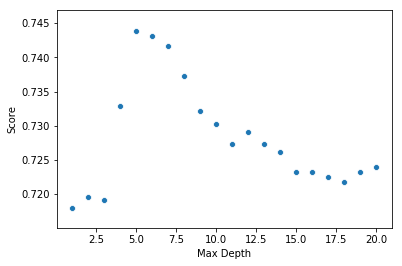

In [0]:
# Write your code here.

# -------------------

sns.scatterplot(x=cv_scores.index, y=cv_scores.values)
plt.xlabel('Max Depth')
plt.ylabel('Score')

cv_scores.idxmax()
# Max depth of 5 was chosen both times.

# -------------------

2. Based on the cross validations, what value of the max_depth parameter would you use to train a RF on this data set? 

___
## __Answer__:
5
___

3. Using the train_test_split function, write code to do cross validation. Do not use functions from sklearn other than RandomForestClassifier. 

the accuracy on the: 
	 training data is 0.716
	 testing data is 0.728
the accuracy on the: 
	 training data is 0.716
	 testing data is 0.717
the accuracy on the: 
	 training data is 0.715
	 testing data is 0.734
the accuracy on the: 
	 training data is 0.719
	 testing data is 0.715
the accuracy on the: 
	 training data is 0.724
	 testing data is 0.697
the accuracy on the: 
	 training data is 0.716
	 testing data is 0.728
the accuracy on the: 
	 training data is 0.723
	 testing data is 0.717
the accuracy on the: 
	 training data is 0.716
	 testing data is 0.734
the accuracy on the: 
	 training data is 0.721
	 testing data is 0.717
the accuracy on the: 
	 training data is 0.726
	 testing data is 0.699
the accuracy on the: 
	 training data is 0.719
	 testing data is 0.73
the accuracy on the: 
	 training data is 0.743
	 testing data is 0.717
the accuracy on the: 
	 training data is 0.717
	 testing data is 0.741
the accuracy on the: 
	 training data is 0.723
	 testing data is 0.719
the acc

5

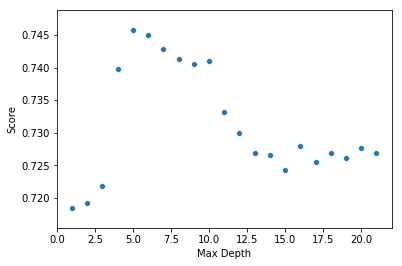

In [0]:
# Write your code here. 

# -------------------


depths = list(range(1, 22))
cv_scores = pd.Series(index=depths)

cv = 5
training_set_size = len(y_train)
random_indices = np.random.permutation(training_set_size)
fractional_splits = np.concatenate(([0], np.repeat(1/cv, cv).cumsum())) 
integer_splits = np.array(np.floor(fractional_splits * training_set_size),dtype=int)


for max_depth in depths:
  all_val_scores = pd.Series(index=range(cv))
  for f in range(cv):
    # Get indicies of training and validation partitions
    train_partition = np.delete(random_indices, range(*integer_splits[f:f+2]))
    val_partition = random_indices[range(*integer_splits[f:f+2])]

    # Initialize model
    rf_cv3_model = RandomForestClassifier(
        random_state = 0, 
        max_depth = max_depth,
        n_estimators = 50, 
        max_features = 0.2
    )

    # Fit and score model
    _, val_score = fit_and_score_model(
        rf_cv3_model, 
        x_train.iloc[train_partition],
        x_train.iloc[val_partition],
        y_train.iloc[train_partition],
        y_train.iloc[val_partition]
    )
    all_val_scores.loc[f] = val_score
    
  cv_scores.loc[max_depth] = all_val_scores.mean()

sns.scatterplot(x=cv_scores.index, y=cv_scores.values)
plt.xlabel('Max Depth')
plt.ylabel('Score')

cv_scores.idxmax()
# Max depth of 5 was chosen both times.
# -------------------

4. Compare your RF model to a logistic regression. What model is more accurate? 

In [0]:
from sklearn.linear_model import LogisticRegressionCV

# Write your code here.  

# -------------------

logregcv = LogisticRegressionCV(penalty='l2', solver='lbfgs', cv=5)
train_score, test_score = fit_and_score_model(logregcv, x_train, x_test, y_train, y_test)

# -------------------

the accuracy on the: 
	 training data is 0.717
	 testing data is 0.717


# Reflection
As this is an _Analytics in Action_ course, we should think about how valuable our models are with respect to real-world applications. Position yourself as an employee of Wikipedia, and answer the following questions

1. Are your models useful to your company in detecting page vanadalism? Why or why not?

___
## __Answer__:

___

2. What other information about the edits (i.e. feature variables not in the dataset) could be useful to detect vandalism?

___
## __Answer__:

Location data of the editor, perhaps
___

3. The findings in this work centre around the Language Wiki page. Do you think these methods would extend to other pages too?

___
## __Answer__:

No. Different categories of pages are likely to have different behaviors with regards to vandalism.
___